In [2]:
%load_ext autoreload
%autoreload 2

In [3]:

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])
Legend._ncol = property(lambda self: self._ncols)

In [4]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd
from utils.helpers import to_pow_10


In [5]:
results_dir = Path("scratch") / "results"
figures_dir = Path("scratch") / "figures"
figures_dir.mkdir(exist_ok=True, parents=True)


def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# stats_df = combine_dfs("bsbm_stats*.csv", results_dir)
# timings_df = combine_dfs("bsbm_timings*.csv", results_dir)
modes = {
    "bsbm": "BSBM",
    "dbpedia": "DBpedia",
}
mode = "bsbm"
timings_df = pd.read_csv(Path("scratch") / "results" / mode / f"{mode}_timings_all.csv")
stats_df = pd.read_csv(Path("scratch") / "results" / mode / f"{mode}_stats_all.csv")

In [20]:
timings_df[(timings_df["query_type"] == "index") & (timings_df["engine"] == "Qlever") & (timings_df["difficulty"] == "hard")].sort_values("size")

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
640,2418,3,1,0.117227,0,Qlever,hard,index,-1.0
641,2418,3,1,0.008546,1,Qlever,hard,index,-1.0
642,2418,3,1,0.007143,2,Qlever,hard,index,-1.0
643,2418,3,1,0.006427,3,Qlever,hard,index,-1.0
644,2418,3,1,0.006280,4,Qlever,hard,index,-1.0
...,...,...,...,...,...,...,...,...,...
4096,383751,5,1000,1.050992,124,Qlever,hard,index,-1.0
4097,383751,5,1000,1.047432,125,Qlever,hard,index,-1.0
4098,383751,5,1000,1.050809,126,Qlever,hard,index,-1.0
4099,383751,5,1000,1.053349,127,Qlever,hard,index,-1.0


In [7]:
import numpy as np
timings_df = timings_df[timings_df["elapsed_time"].replace([np.inf, -np.inf], np.nan).notna()]

In [8]:
hard_timings = timings_df[timings_df["difficulty"] == "hard"]
hard_timings

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
128,2418,3,1,0.467319,0,Fuseki + RDFTensor,hard,embedded,-1.0
129,2418,3,1,0.026075,1,Fuseki + RDFTensor,hard,embedded,-1.0
130,2418,3,1,0.020496,2,Fuseki + RDFTensor,hard,embedded,-1.0
131,2418,3,1,0.025560,3,Fuseki + RDFTensor,hard,embedded,-1.0
132,2418,3,1,0.020492,4,Fuseki + RDFTensor,hard,embedded,-1.0
...,...,...,...,...,...,...,...,...,...
4482,383751,5,1000,1.803545,125,Qlever (no Tensor Vocabulary),hard,index,-1.0
4483,383751,5,1000,1.863501,126,Qlever (no Tensor Vocabulary),hard,index,-1.0
4484,383751,5,1000,1.804504,127,Qlever (no Tensor Vocabulary),hard,index,-1.0
4872,3577077,6,10000,9.192327,1,Qlever,hard,index,-1.0


In [9]:
# timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['Fuseki + RDFTensor', 'Qlever', 'Qlever (no Tensor Vocabulary)']
Length: 3, dtype: str

In [10]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [11]:
engines = list(timings_df["engine"].unique())
engines.sort()
baseline_engine = engines[0]

from scipy.stats import ttest_ind

def siginificance_level(p_value: float) -> str:
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"
# calculate the median speedup vs the baseline engine for each difficulty + query type + engine + size
# + whether the speedup is statistically significant (using a t-test)
# the baseline engine
def calculate_speedup(
    df: pd.DataFrame, baseline_engine: str, baseline_type: str, relevant_measure: str
) -> pd.DataFrame:
    results = []
    chunks = df.groupby(["difficulty", "query_type", "engine", "estimated_size", "size"])
    for i, group in chunks:
        if group.empty or (
            (group["query_type"] == baseline_type).all() and (group["engine"] == baseline_engine).all()
        ):
            continue
        baseline_group = df[
            (df["difficulty"] == group["difficulty"].iloc[0])
            & (df["query_type"] == baseline_type)
            & (df["engine"] == baseline_engine)
            & (df["estimated_size"] == group["estimated_size"].iloc[0])
            & (df["size"] == group["size"].iloc[0])
        ]
        if baseline_group.empty:
            continue
        measure_group = group[relevant_measure]
        measure_baseline_group = baseline_group[relevant_measure]
        t_stat, p_value = ttest_ind(measure_group, measure_baseline_group, equal_var=False)
        speedup = measure_baseline_group.mean() / measure_group.mean()
        results.append(
            {
                "difficulty": group["difficulty"].iloc[0],
                "query_type": group["query_type"].iloc[0],
                "engine": group["engine"].iloc[0],
                "estimated_size": group["estimated_size"].iloc[0],
                "size": group["size"].iloc[0],
                "speedup": speedup,
                "p_value": p_value,
                "significance_level": siginificance_level(p_value)
            }
        )
    return pd.DataFrame(results)


calculate_speedup(timings_df, baseline_engine, "embedded", "elapsed_time")


,difficulty,query_type,engine,estimated_size,size,speedup,p_value,significance_level
0,easy,embedded,Qlever,1,2418,3.580417,2.359061e-04,***
1,easy,embedded,Qlever,10,5595,6.152836,6.367959e-07,***
2,easy,embedded,Qlever,100,42417,10.592549,1.623630e-28,***
3,easy,embedded,Qlever,1000,383751,25.856777,1.019760e-87,***
4,easy,embedded,Qlever,10000,3577077,32.850041,1.274671e-112,***
5,easy,embedded,Qlever (no Tensor Vocabulary),1,2418,4.009227,1.326435e-04,***
6,easy,embedded,Qlever (no Tensor Vocabulary),10,5595,2.518315,2.443156e-04,***
7,easy,embedded,Qlever (no Tensor Vocabulary),100,42417,1.634490,8.043517e-09,***
8,easy,embedded,Qlever (no Tensor Vocabulary),1000,383751,1.676825,4.769765e-45,***
9,easy,embedded,Qlever (no Tensor Vocabulary),10000,3577077,1.623432,2.457988e-64,***


In [12]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [13]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'Fuseki + RDFTensor': 'C0',
 'Qlever': 'C1',
 'Qlever (no Tensor Vocabulary)': 'C2'}

In [14]:
import matplotlib.pyplot as plt
import tikzplotlib
import seaborn as sns
import numpy as np

plt.rc("text", usetex=True)
plt.rc("text.latex", preamble="""\\usepackage{amsmath}""")
plt.style.use("fivethirtyeight")
# set background color to white of the figure and axes
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

palette = sns.color_palette('colorblind').as_hex()
def adjust_lightness(color, amount=1.1):
    import matplotlib.colors as mc
    import colorsys

    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], np.maximum(0, np.minimum(1, amount * c[1])), c[2])

plt.rcParams.update({'errorbar.capsize': 2})

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [3577077, 35177974] [12.823801755905151, 330.6262195372155] existing points [2418, 5595, 42417, 383751, 3577077] [0.0152364149689674, 0.022414982318878098, 0.1118286177515983, 1.1527461409568787, 12.823801755905151]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - embedded: [3577077, 35177974] [8.164174772799015, 210.90398737702822] existing points [2418, 5595, 42417, 383751, 3577077] [0.0051420331001281, 0.01315751299262045, 0.0881910510361194, 0.73478202521801, 8.164174772799015]


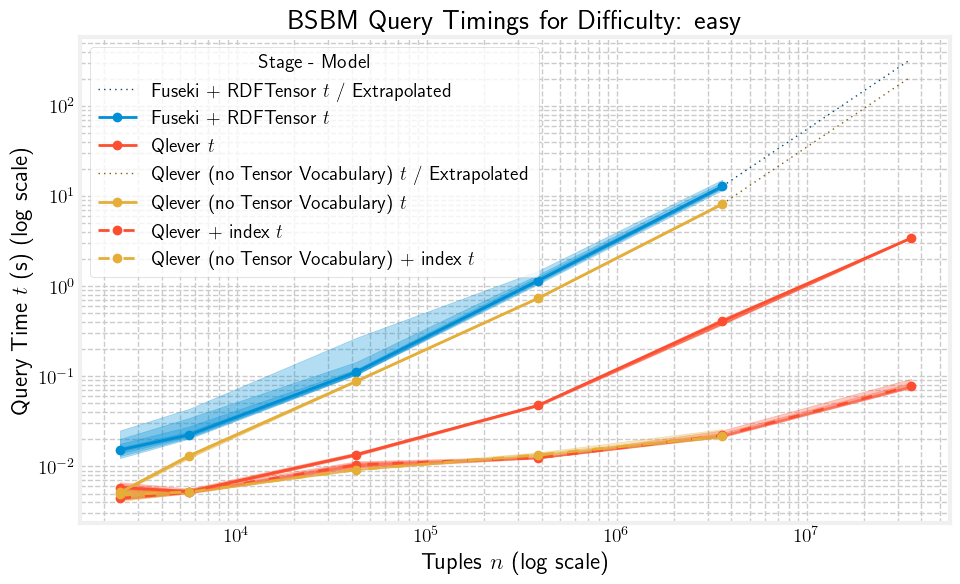

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [5595, 42417, 383751, 3577077, 35177974] [2.028603248298168, 323.0432474231497, 29382.661150261352, 2582179.5618510777, 250036204.1418462] existing points [2418, 5595] [0.0110475048422813, 2.028603248298168]
Extrapolated sizes for Qlever - embedded: [42417, 383751, 3577077, 35177974] [18.26907752081752, 1639.1352315524073, 143845.57626265203, 13926668.167131461] existing points [2418, 5595, 42417] [0.0058197677135467, 0.1397273205220699, 18.26907752081752]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - embedded: [5595, 42417, 383751, 3577077, 35177974] [3.0069266743957996, 480.2610321965554, 43703.221642981, 3840883.6617222126, 371920418.6507957] existing points [2418, 5595] [0.0269869193434715, 3.0069266743957996]
Extrapolated sizes for Qlever - index: [3577077, 35177974] [9.192326791584492, 22.9560240943727] exis

/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


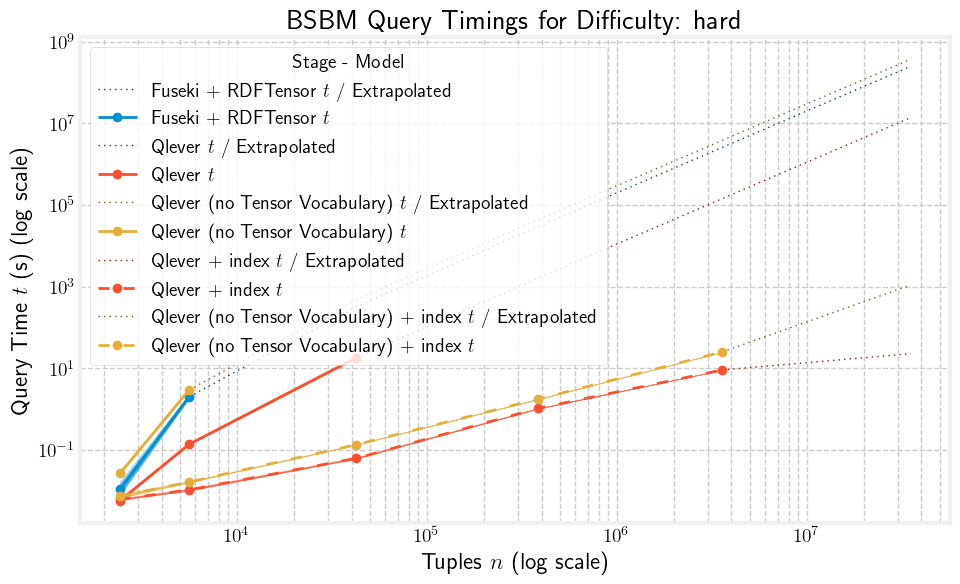

Quantiles [0.05, 0.95]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [3577077, 35177974] [12.823801755905151, 330.6262195372155] existing points [2418, 5595, 42417, 383751, 3577077] [0.0152364149689674, 0.022414982318878098, 0.1118286177515983, 1.1527461409568787, 12.823801755905151]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - embedded: [3577077, 35177974] [8.164174772799015, 210.90398737702822] existing points [2418, 5595, 42417, 383751, 3577077] [0.0051420331001281, 0.01315751299262045, 0.0881910510361194, 0.73478202521801, 8.164174772799015]


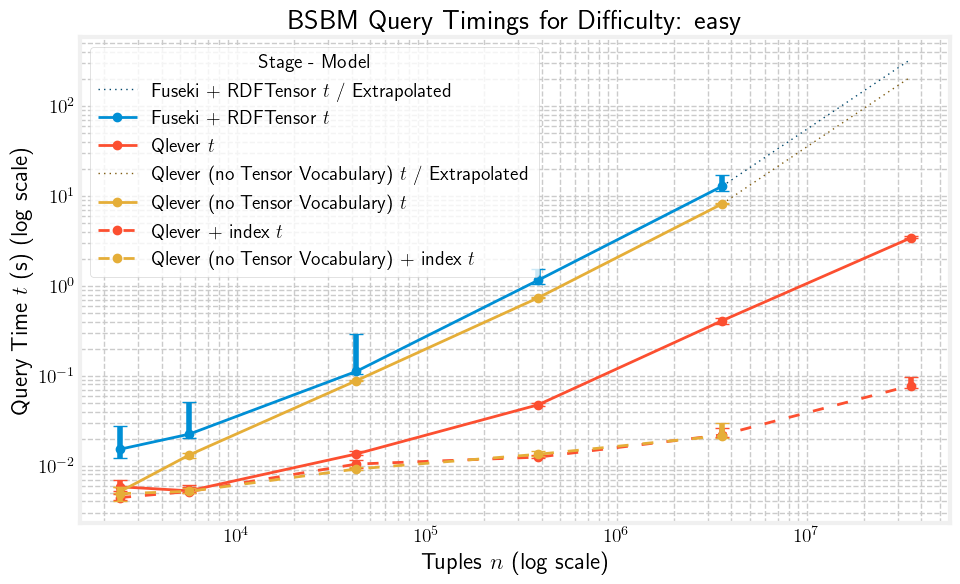

Quantiles [0.05, 0.95]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [5595, 42417, 383751, 3577077, 35177974] [2.028603248298168, 323.0432474231497, 29382.661150261352, 2582179.5618510777, 250036204.1418462] existing points [2418, 5595] [0.0110475048422813, 2.028603248298168]
Extrapolated sizes for Qlever - embedded: [42417, 383751, 3577077, 35177974] [18.26907752081752, 1639.1352315524073, 143845.57626265203, 13926668.167131461] existing points [2418, 5595, 42417] [0.0058197677135467, 0.1397273205220699, 18.26907752081752]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - embedded: [5595, 42417, 383751, 3577077, 35177974] [3.0069266743957996, 480.2610321965554, 43703.221642981, 3840883.6617222126, 371920418.6507957] existing points [2418, 5595] [0.0269869193434715, 3.0069266743957996]
Extrapolated sizes for Qlever - index: [3577077, 35177974] [9.192326791584492, 22.9560240943727] existing points [2418, 5595, 42417, 383751, 3577077] [0.0061991587281227, 0.01066071167588230

/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


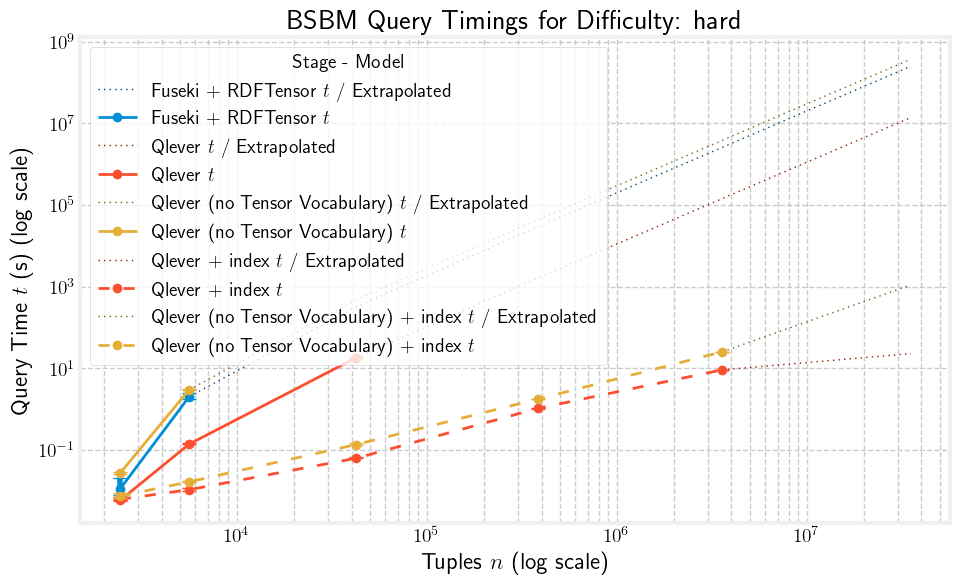

In [37]:
from numpy.polynomial import Polynomial, Hermite, Chebyshev


def extrapolate_missing_sizes(
    df,
    possible_sizes,
    relevant_measure,
    fns=[
        lambda x: x**2,
        lambda x: x,
        lambda x : np.sqrt(x),
        lambda x: np.ones_like(x),
    ],
):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]

    missing_sizes = [s for s in possible_sizes if s not in df_filtered["size"].unique()]
    missing_sizes.sort()
    # missing_sizes = missing_sizes[:-1]
    missing_sizes = np.array(missing_sizes)
    if df_filtered.empty or len(missing_sizes) == 0:
        return None
    x_data = df_filtered["size"].values
    y_data = df_filtered[relevant_measure].values

    poly = Polynomial.fit(x_data, y_data, deg=2)
    y_pred = poly(missing_sizes)
    # if (y_pred <= 0).any():
    # Phi = np.column_stack([fn(x_data) for fn in fns])
    # # calculate the coefficients using least squares with regularization to prevent overfitting
    # lbd = 0.0
    # coefs = (
    #     np.linalg.inv(Phi.T @ Phi / x_data.shape[0] + lbd * np.eye(Phi.shape[1]))
    #     @ Phi.T
    #     @ y_data
    # )
    # print("Coefficients for extrapolation:", coefs)
    # y_pred = np.dot(coefs, [fn(missing_sizes) for fn in fns])
    extrapolated_df = pd.DataFrame(
        {
            "size": missing_sizes,
            relevant_measure: y_pred,
        }
    )
    if extrapolated_df.empty:
        return None
    # add last known size and measure to the extrapolated df to make the plot look better
    last_known_size = df_filtered["size"].max()
    last_known_measure = df_filtered[df_filtered["size"] == last_known_size][
        relevant_measure
    ].values[0]
    extrapolated_df = pd.concat(
        [
            pd.DataFrame(
                {"size": [last_known_size], relevant_measure: [last_known_measure]}
            ),
            extrapolated_df,
        ],
        ignore_index=True,
    )
    return extrapolated_df


def fit_to_fn(df, relevant_measure, fn: (lambda x: x)):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]
    if df_filtered.empty:
        return None
    x_data = df_filtered["size"].values
    # y_data = df_filtered[relevant_measure].values
    const = x_data[0] if x_data[0] > 0 else 1
    x_data_fn = fn(x_data / const) * const
    Phi = np.vstack([x_data_fn, np.ones(len(x_data_fn))])
    coeffs = np.linalg.lstsq(Phi, df_filtered[relevant_measure].values, rcond=None)[0]
    a, b = coeffs
    y_fitted = a * x_data_fn + b
    fitted_df = pd.DataFrame(
        {
            "size": x_data,
            relevant_measure: y_fitted,
        }
    )
    return fitted_df


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(
    ax,
    df,
    engine,
    difficulty,
    relevant_measure="elapsed_time",
    extrapolate=True,
    fill_pdf=True,
    pdf_steps=5,
    fit_fn=None,
):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = (
        [0.05, 0.95] if not fill_pdf else np.linspace(0, 1, 1 + pdf_steps * 2).tolist()
    )
    print("Quantiles", quantiles)
    mean_timings = groupings.mean().reset_index()
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    possible_sizes = sorted(df["size"].unique())
    all_extended_dfs = []
    for query_type in QUERY_TYPE:
        for engine in mean_timings["engine"].unique():
            engine_mean = mean_timings[
                (mean_timings["query_type"] == query_type.value)
                & (mean_timings["difficulty"] == difficulty)
                & (mean_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            if engine_mean.empty or engine_quantiles.empty:
                continue

            extrapolated_df = None
            engine_median = engine_median[engine_median[relevant_measure].notna()]
            # extrapolate missing sizes by linear regression

            if extrapolate:
                extrapolated_df = extrapolate_missing_sizes(
                    engine_median, possible_sizes, relevant_measure
                )

            # index are dashed, embedded are solid
            linestyle = (0, (4, 5)) if query_type == QUERY_TYPE.INDEX else "-"
            lbl = f"{engine}"
            if query_type.value != QUERY_TYPE.EMBEDDED.value:
                lbl += f" + {query_type.value}"
            lbl += " $t$"
            if (
                extrapolated_df is not None
                and not extrapolated_df.empty
                and extrapolated_df.shape
                and (extrapolated_df[relevant_measure] > 0).all()
            ):
                all_extended_dfs.append(extrapolated_df)
                print(
                    f"Extrapolated sizes for {engine} - {query_type.value}: {extrapolated_df['size'].tolist()}",
                    extrapolated_df[relevant_measure].tolist(),
                    "existing points",
                    engine_median["size"].tolist(),
                    engine_median[relevant_measure].tolist(),
                )
                ax.plot(
                    extrapolated_df["size"],
                    extrapolated_df[relevant_measure],
                    linestyle=(0, (1, 3)),
                    label=f"{lbl} / Extrapolated",
                    color=adjust_lightness(colors[engine], 0.5),
                    linewidth=1,
                )
            if fit_fn is not None and fit_fn is not False:
                fit_fn = (
                    fit_fn if isinstance(fit_fn, type(lambda: None)) else lambda x: x
                )
                fitted_df = fit_to_fn(
                    engine_median,
                    relevant_measure,
                    fn=fit_fn,
                )
                if fitted_df is not None and not fitted_df.empty:
                    ax.plot(
                        fitted_df["size"],
                        fitted_df[relevant_measure],
                        linestyle=(0, (5, 10)),
                        label=f"{lbl} / Fit",
                        color=adjust_lightness(colors[engine], 0.8),
                        linewidth=1,
                    )
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o",
                linestyle=linestyle,
                label=lbl,
                color=colors[engine],
                linewidth=2,
            )
            if fill_pdf:
                if engine_median["size"].shape[0] > 1:
                    for i in range(0, pdf_steps - 1):
                        ax.fill_between(
                            engine_quantiles["size"],
                            engine_quantiles[quantiles[pdf_steps - 1 - i]],
                            engine_quantiles[quantiles[pdf_steps + 1 + i]],
                            color=colors[engine],
                            alpha=0.3,
                        )
            else:
                ax.errorbar(
                    engine_median["size"],
                    engine_median[relevant_measure],
                    yerr=[
                        engine_median[relevant_measure] - engine_quantiles[0.05],
                        engine_quantiles[0.95] - engine_median[relevant_measure],
                    ],
                    barsabove=True,
                    capsize=5,
                    fmt="none",
                    # label=f"5\%-95\% quantiles ({engine})",
                    color=colors[engine],
                )
    return pd.concat(all_extended_dfs) if all_extended_dfs else None


overview_dir = figures_dir / "overview"
overview_dir.mkdir(exist_ok=True, parents=True)


def calc_extra_ticks(series: pd.Series, tweens=[2, 3, 4, 5, 6, 7, 8, 9]):
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    min_size = int(np.log10(series.min())) - 1
    max_size = int(np.log10(series.max())) + 2

    extra_ticks = [10**i * tween for i in range(min_size, max_size) for tween in tweens]
    return extra_ticks


extra_y_ticks = calc_extra_ticks(timings_df["elapsed_time"])
extra_x_ticks = calc_extra_ticks(timings_df["size"])
for fill_pdf in [True, False]:
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # ax = axes[i] if len(difficulties) > 1 else axes
        # set the suxbtitle to the difficulty

        extended_dfs = plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            fill_pdf=fill_pdf,
            fit_fn=False,
        )
        complete_plotted_df = (
            pd.concat([timings_df, extended_dfs])
            if extended_dfs is not None
            else timings_df
        )
        extra_y_ticks_plt = calc_extra_ticks(complete_plotted_df["elapsed_time"])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Tuples $n$ (log scale)")
        ax.set_ylabel("Query Time $t$ (s) (log scale)")
        ax.set_title(f"{mode.upper()} Query Timings for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        fill_str = "_filled" if fill_pdf else ""
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}{fill_str}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=2, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}_legend{fill_str}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=5, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(overview_dir / f"{mode}_timings_{difficulty}{fill_str}.png")
        plt.show()

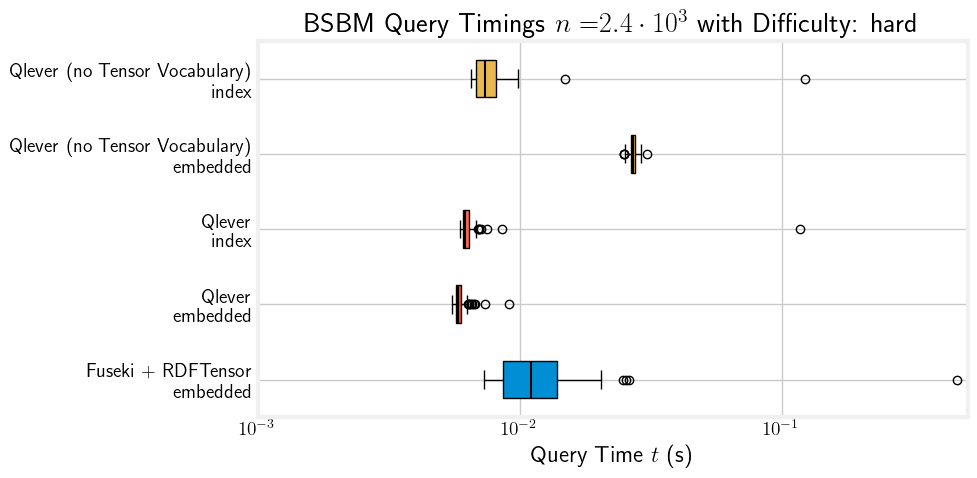

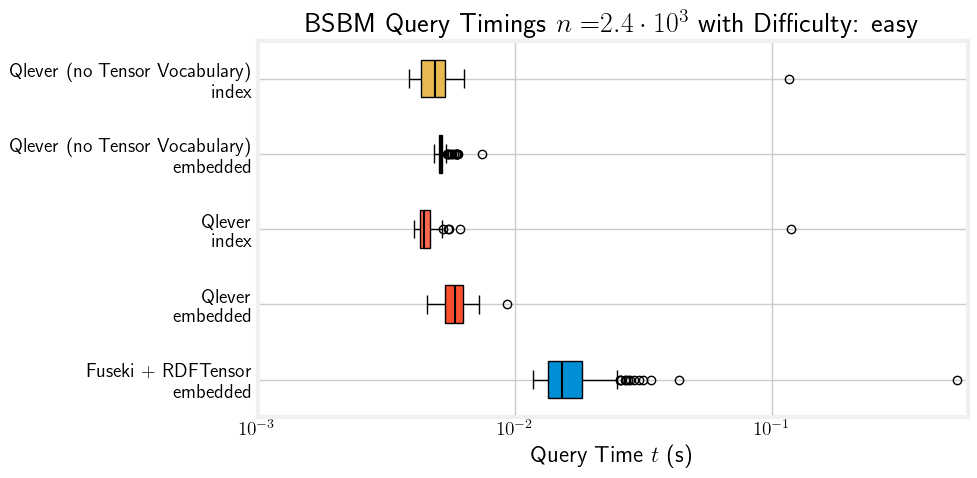

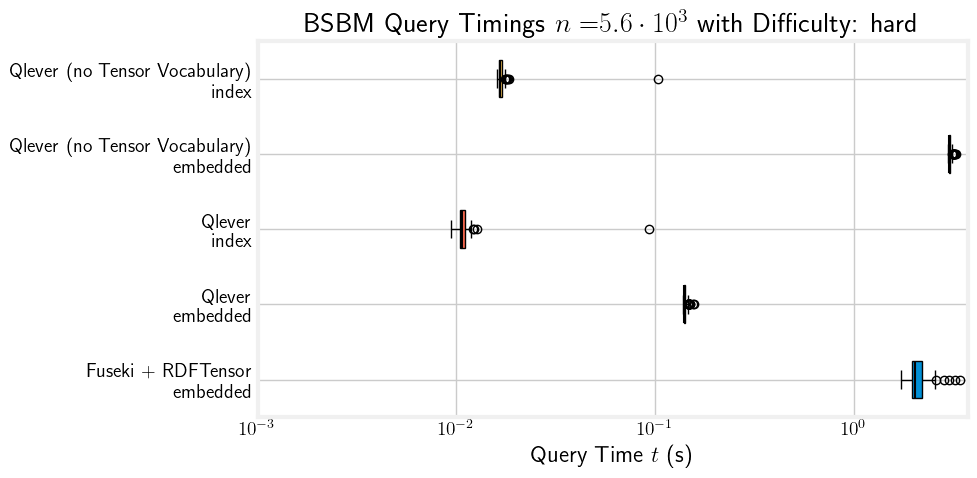

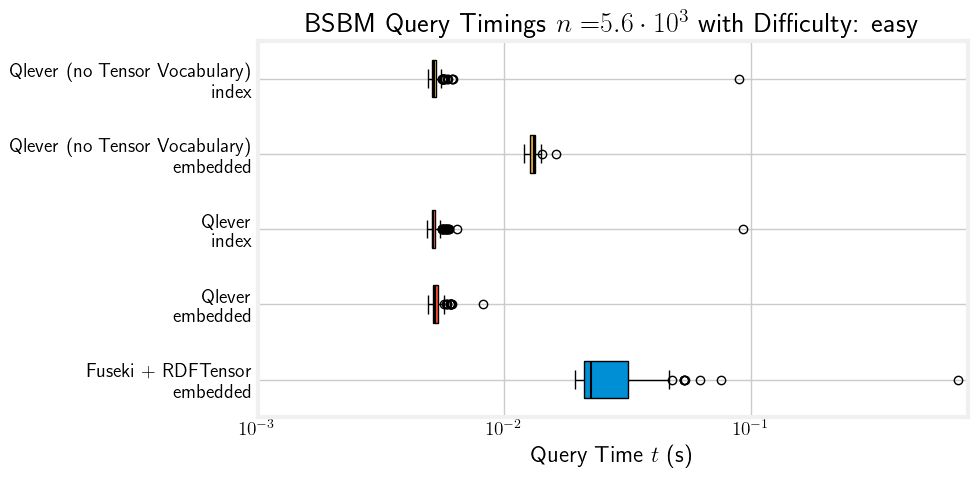

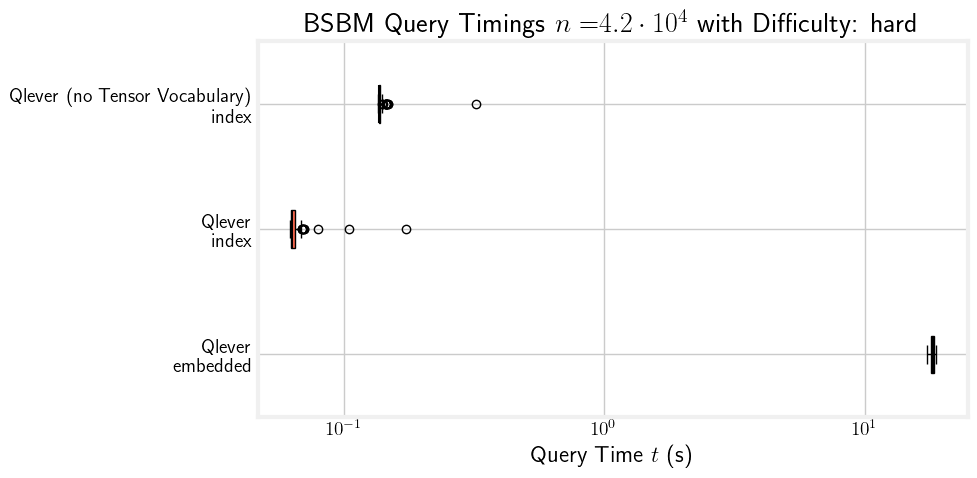

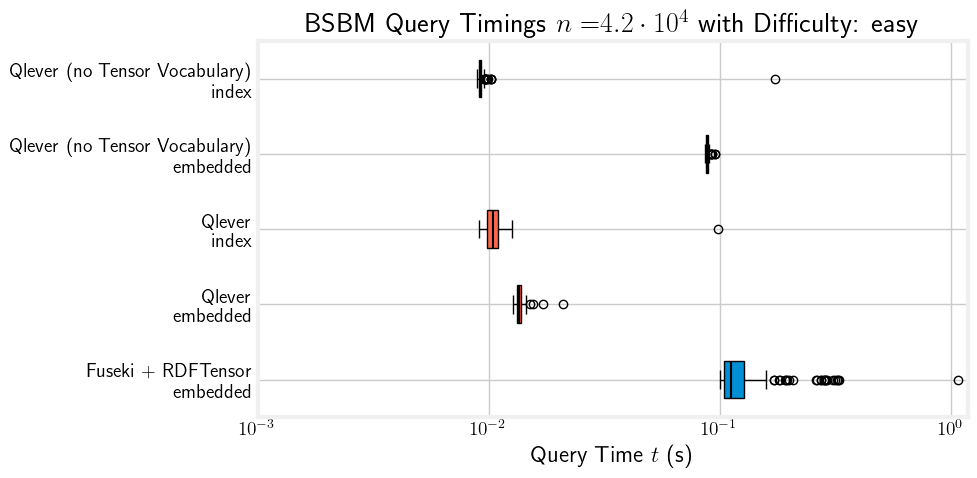

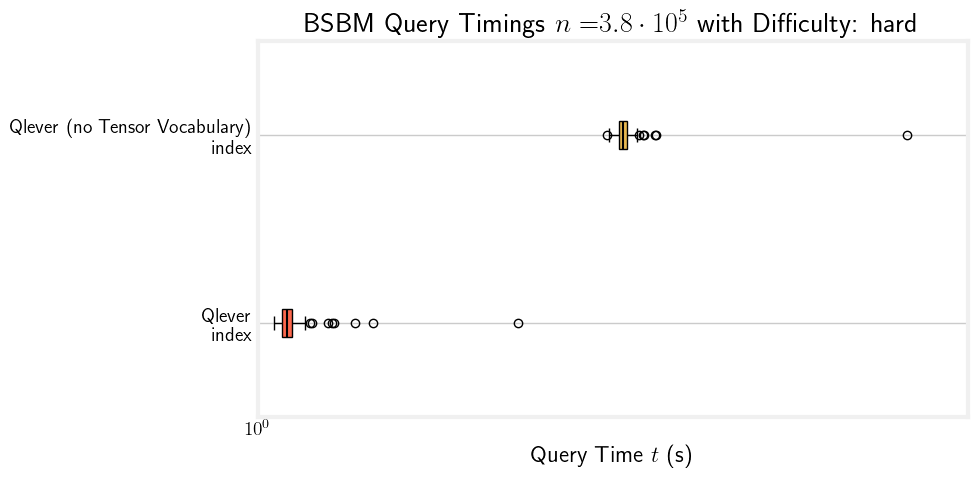

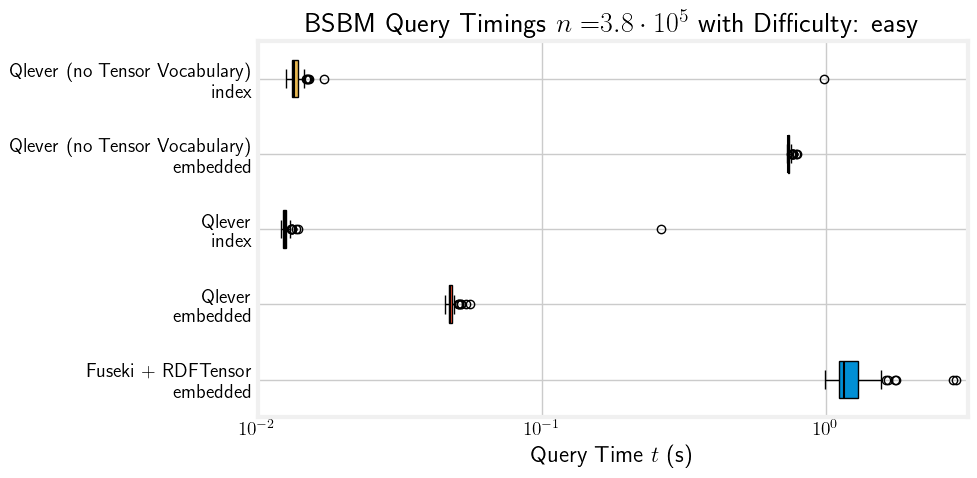

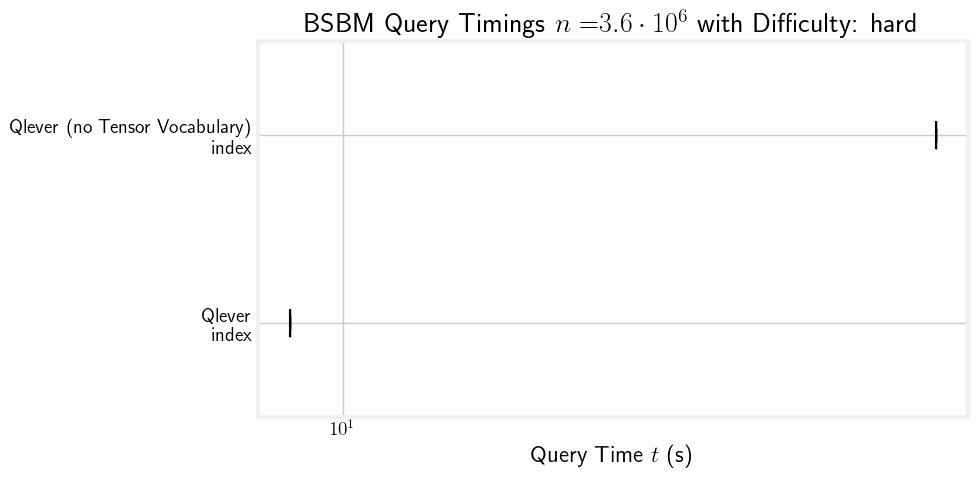

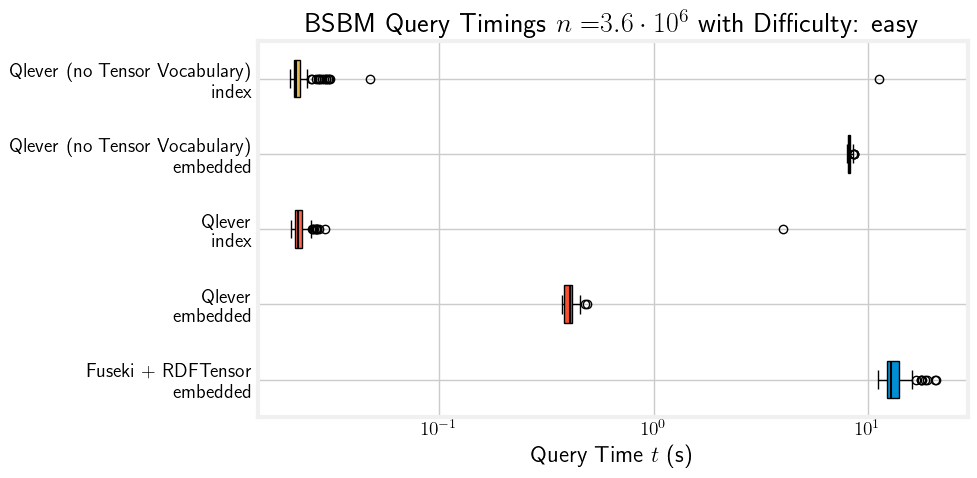

No measures for size 35177974 and difficulty hard


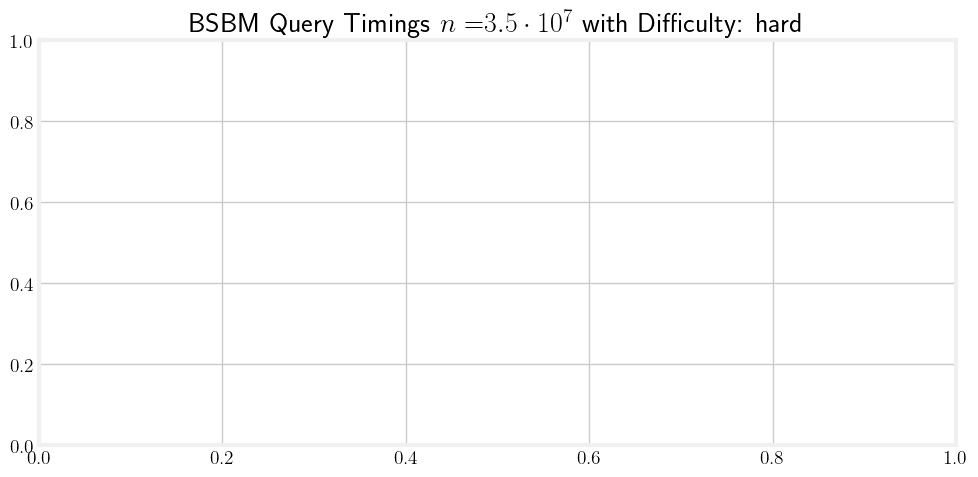

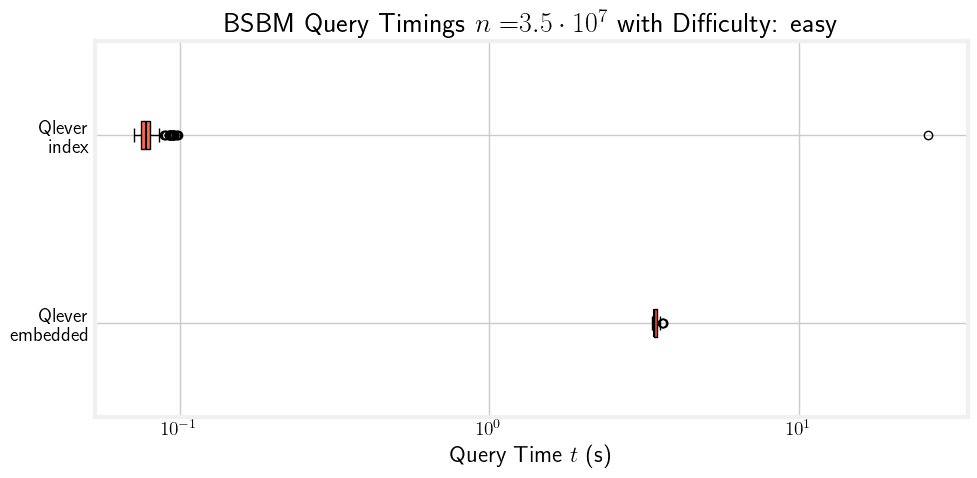

In [49]:
def plot_boxplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    size: int,
    difficulty: str,
    relevant_measure: str = "elapsed_time",
):
    ax.set_title(
        f" {modes[mode]} Query Timings $n=${to_pow_10(size)} with Difficulty: {difficulty}"
    )
    size_df = df[df["size"] == size]
    engine_types = size_df.apply(
        lambda row: (row["engine"], row["query_type"]), axis=1
    ).unique()

    tick_labels = list(engine_types)
    measures: list[pd.Series] = [
        size_df[
            (size_df["difficulty"] == difficulty)
            & (size_df["engine"] == engine)
            & (size_df["query_type"] == query_type)
        ][relevant_measure]
        for engine, query_type in tick_labels
    ]
    # filter infinite and nan values from measures and corresponding tick labels
    measures_f = [
        measures[i].replace([np.inf, -np.inf], np.nan).dropna()
        for i in range(len(measures))
    ]
    measures = [
        measures_f[i] for i in range(len(measures_f)) if not measures_f[i].shape[0] == 0
    ]
    tick_labels = [
        tick_labels[i]
        for i in range(len(tick_labels))
        if not measures_f[i].shape[0] == 0
    ]
    if len(measures) == 0:
        print(f"No measures for size {size} and difficulty {difficulty}")
        return
    all_measures = pd.concat(measures)
    bplot = ax.boxplot(
        measures,
        tick_labels=[f"{engine}\n{query_type}" for engine, query_type in tick_labels],
        vert=False,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        # showfliers=False,
    )
    ax.set_xlabel("Query Time $t$ (s)")
    ax.set_xscale("log")
    ax.set_xticklabels([], minor=True)
    # fill with colors
    for patch, (engine, query_type) in zip(bplot["boxes"], tick_labels):
        patch.set_facecolor(
            adjust_lightness(colors[engine])
            if query_type == QUERY_TYPE.INDEX.value
            else colors[engine]
        )
    if abs(all_measures.min() - all_measures.max()) < 10:
        min_power = int(np.floor(np.log10(all_measures.min())))
        max_power = int(np.ceil(np.log10(all_measures.max())))
        ax.set_xlim(left=10**min_power, right=all_measures.max()*1.1)


boxplots_dir = figures_dir / "boxplots"
boxplots_dir.mkdir(exist_ok=True, parents=True)
for est_size in timings_df["estimated_size"].unique():
    for difficulty in difficulties[::-1]:
        fig, ax = plt.subplots(1, figsize=(10, 5))
        eval_size = timings_df[timings_df["estimated_size"] == est_size][
            "size"
        ].unique()[0]
        plot_boxplot(ax, timings_df, eval_size, difficulty)
        plt.tight_layout()
        tikzplotlib.save(
            boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=2, 
                    extra x ticks={"""
                + ",".join(map(str, extra_y_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="0.7\\textwidth",
            axis_width="1.25\\textwidth",
        )
        plt.savefig(boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.png")
        plt.show()

In [50]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine,mem_usage_mb
0,2026-04-20 14:41:58.652943,0.0,382889984,-1,-1,1,2418,3,easy,embedded,1,Fuseki + RDFTensor,365.152344
1,2026-04-20 14:41:58.784801,515.8,393256960,-1,-1,1,2418,3,easy,embedded,1,Fuseki + RDFTensor,375.039062
2,2026-04-20 14:41:58.914348,548.1,407969792,-1,-1,1,2418,3,easy,embedded,1,Fuseki + RDFTensor,389.070312
3,2026-04-20 14:41:59.045306,1297.8,431960064,-1,-1,1,2418,3,easy,embedded,1,Fuseki + RDFTensor,411.949219
4,2026-04-20 14:41:59.192086,1465.4,441155584,-1,-1,1,2418,3,easy,embedded,1,Fuseki + RDFTensor,420.718750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55977,2026-04-20 17:04:26.849833,101.1,2278830080,-1,-1,1,35177974,7,hard,index,100000,Qlever (no Tensor Vocabulary),2173.261719
55978,2026-04-20 17:04:26.988453,101.0,2282557440,-1,-1,1,35177974,7,hard,index,100000,Qlever (no Tensor Vocabulary),2176.816406
55979,2026-04-20 17:04:27.127695,100.5,2286678016,-1,-1,1,35177974,7,hard,index,100000,Qlever (no Tensor Vocabulary),2180.746094
55980,2026-04-20 17:04:27.266925,100.6,2292240384,-1,-1,1,35177974,7,hard,index,100000,Qlever (no Tensor Vocabulary),2186.050781


In [51]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


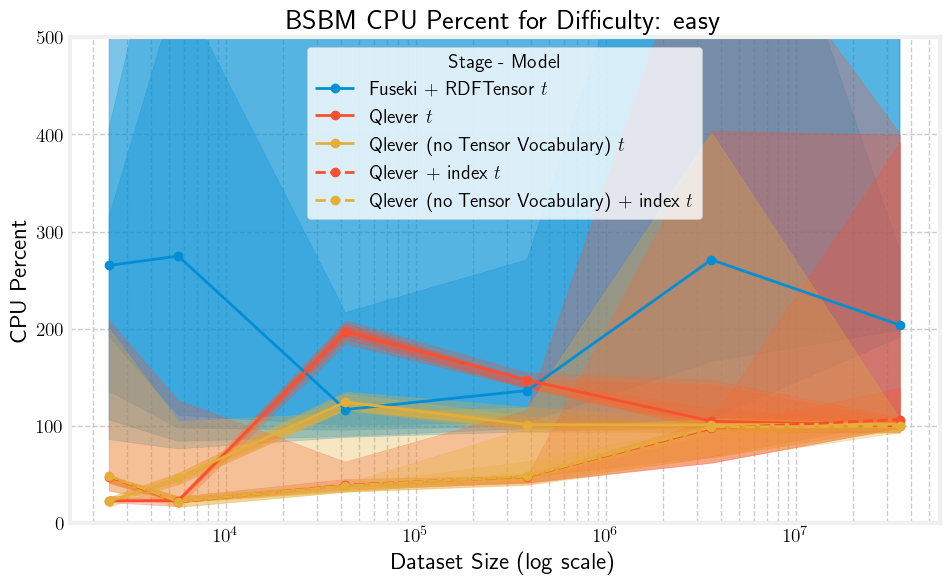

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


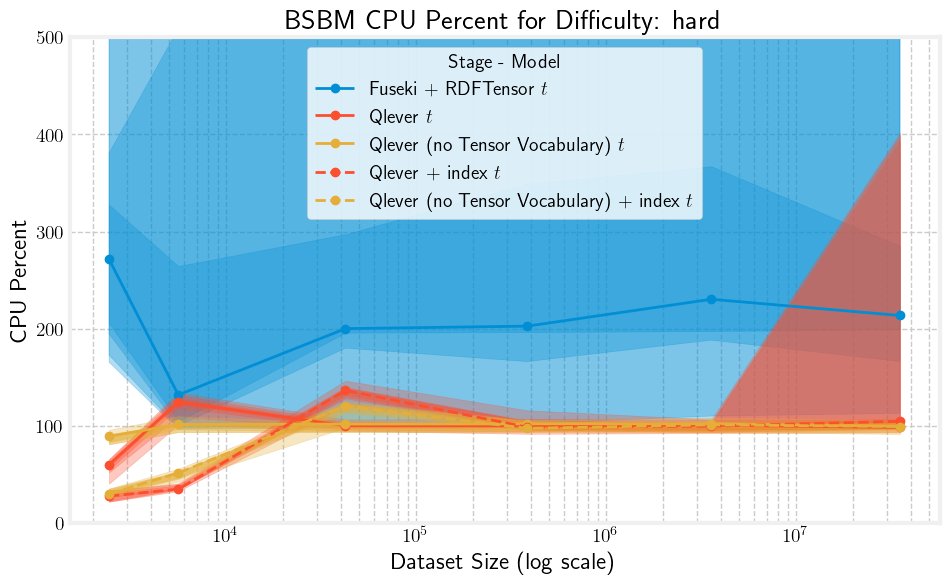

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


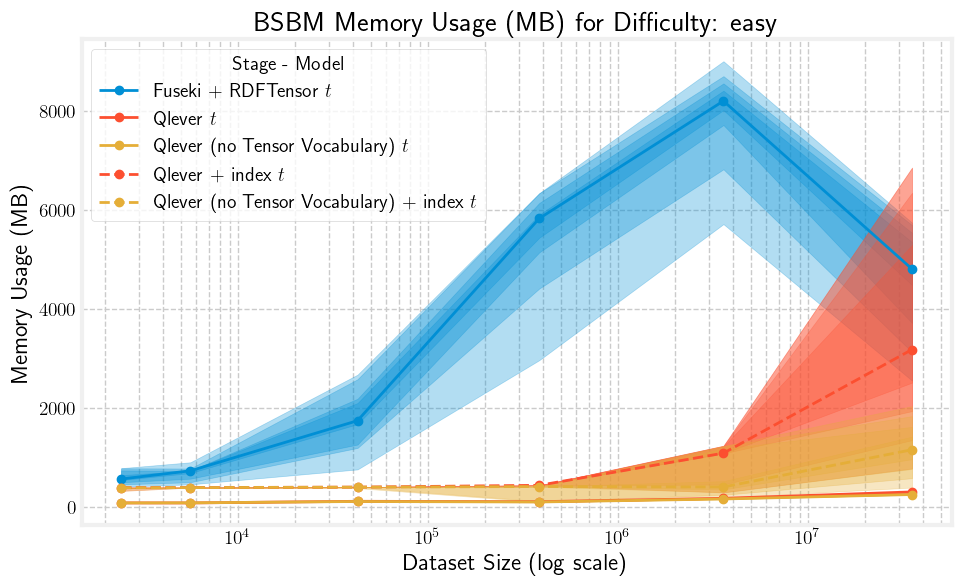

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


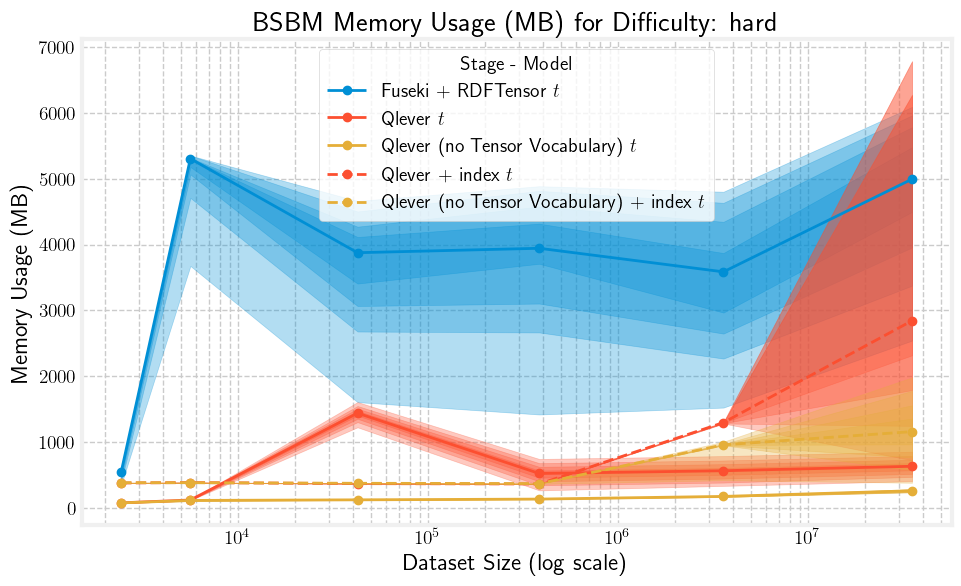

In [52]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_stats_map = {
    "cpu_percent": "CPU Percent",
    "mem_usage_mb": "Memory Usage (MB)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_stats_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            stats_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=True,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "cpu_percent":
            ax.set_ylim(0, 500)
            ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()


Quantiles [0.05, 0.95]


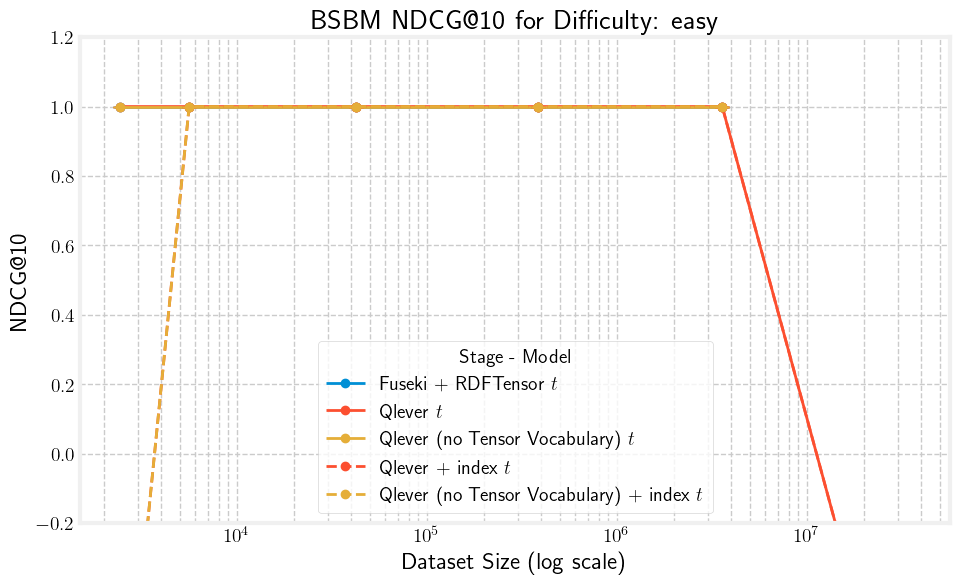

Quantiles [0.05, 0.95]


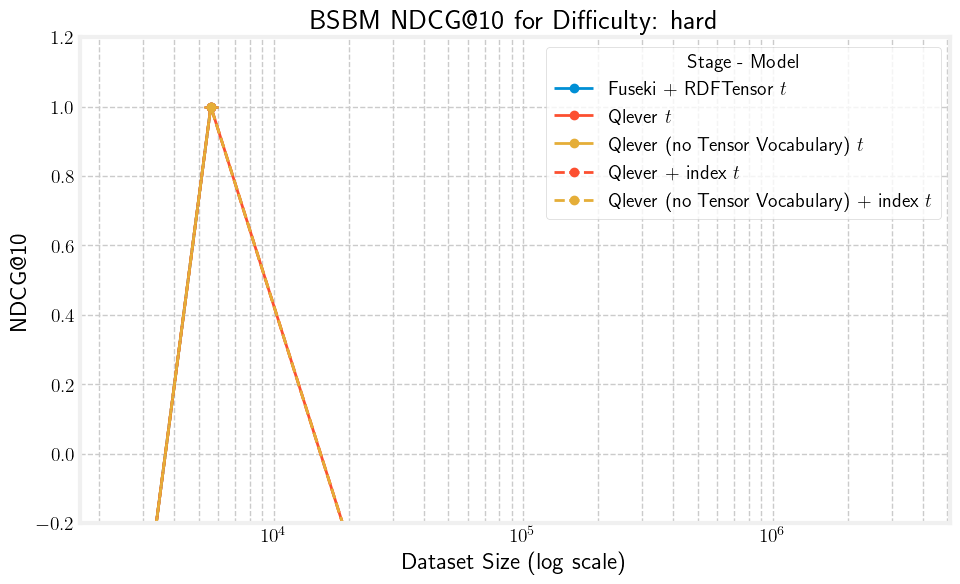

In [53]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_measure_map = {
    "ndcg_score": "NDCG@10",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_measure_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        ax.set_ylim(-0.2, 1.2)
        ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()
